## Just the import statements

## this is the comparison note  book of the train / test data and the classes

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.decomposition import PCA
import tensorflow as tf

2026-05-11 22:24:19.822246: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-11 22:24:19.890431: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-11 22:24:21.257592: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## pipeline structure 
- “MobileNetV2 extracts 1280‑D features. Those features are used (1) to train real SVM classifiers (linear & RBF) for performance evaluation, and (2) to generate PCA/t‑SNE plots for visualization. Then, for teaching purposes, we train SVM on the 2D PCA/t‑SNE coordinates to show what linear vs curved boundaries would look like in those low‑dim projections

# Checking the dimensions of the images 

- doing this to find out if the articture is good enough  or not
- to find out wether the imges are repsenting  the same distribution for the train and the test images 
- this actually gives us the validitly of the data before making any pipeline 
- i will also add the images of the  solar cells taken by hand from the esp32 
- this will make the assumption even more clear  

## Class Distribution Plot

## first using the base model a light model for having something to make the base asssumption on 


- using the mobile-net-v2 model 

In [6]:
model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

/tmp/ipykernel_21869/1246004902.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = tf.keras.applications.MobileNetV2(
2026-05-11 22:29:45.958729: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Image Preprocessing

In [7]:
IMG_SIZE = 224

def preprocess_image(path):
    img = tf.keras.preprocessing.image.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img = tf.keras.preprocessing.image.img_to_array(img)
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img

##  Load Dataset & Extract Features

In [9]:
base_path = "cropped_dataset"

splits = ["train", "test"]

features = []
labels = []
split_labels = []

for split in splits:
    split_path = os.path.join(base_path, split)
    
    for class_name in ["clean", "dusty"]:
        class_path = os.path.join(split_path, class_name)
        
        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)
            try:
                img = preprocess_image(img_path)
                img = np.expand_dims(img, axis=0)
                
                feat = model.predict(img, verbose=0)[0]
                
                features.append(feat)
                labels.append(class_name)
                split_labels.append(split)
            except:
                continue

- MobileNetV2 turned each image into a 1280‑dimensional feature vector representing edges, textures, patterns. This is the “meaningful representation” mentioned in the original pipeline.

## Appilying the PCA to do the dimensinality reduction an make some sense out from the dataset

In [10]:
X = np.array(features)

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

## Vivusalization

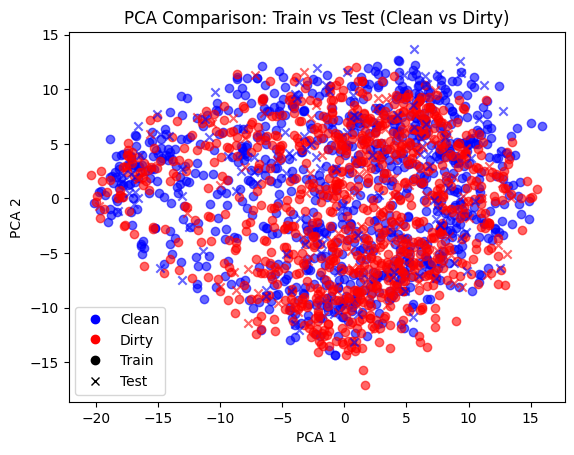

In [11]:
plt.figure()

for i in range(len(X_reduced)):
    x = X_reduced[i][0]
    y = X_reduced[i][1]
    
    color = "blue" if labels[i] == "clean" else "red"
    marker = "o" if split_labels[i] == "train" else "x"
    
    plt.scatter(x, y, c=color, marker=marker, alpha=0.6)

# Legend manually
import matplotlib.lines as mlines

clean = mlines.Line2D([], [], color='blue', marker='o', linestyle='None', label='Clean')
dirty = mlines.Line2D([], [], color='red', marker='o', linestyle='None', label='Dirty')

train = mlines.Line2D([], [], color='black', marker='o', linestyle='None', label='Train')
test = mlines.Line2D([], [], color='black', marker='x', linestyle='None', label='Test')

plt.legend(handles=[clean, dirty, train, test])
plt.title("PCA Comparison: Train vs Test (Clean vs Dirty)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

# Results 
- the results tell me that the data is not linearly seperable 
- we can see there is almost no distinction in the linear nad the clean and dusty classes 
- we will now move to the non-linear dimensionality reduction algo

# Appilying the TSNE - algo

In [12]:
from sklearn.manifold import TSNE

In [14]:
X = np.array(features)

tsne = TSNE(
    n_components=2,
    perplexity=30,     # try 20–50
    learning_rate=200,
    random_state=42
)

X_reduced = tsne.fit_transform(X)

## the non-linear-plot 

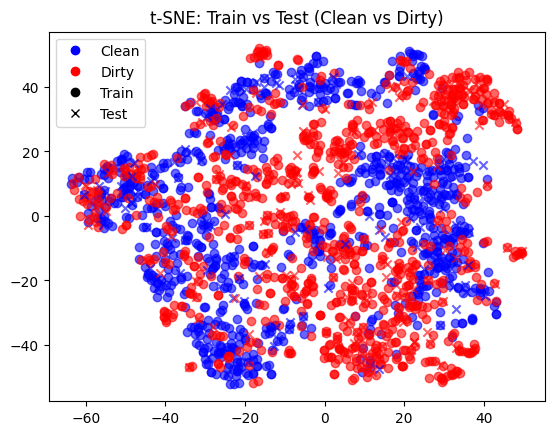

In [15]:
plt.figure()

for i in range(len(X_reduced)):
    x = X_reduced[i][0]
    y = X_reduced[i][1]
    
    color = "blue" if labels[i] == "clean" else "red"
    marker = "o" if split_labels[i] == "train" else "x"
    
    plt.scatter(x, y, c=color, marker=marker, alpha=0.6)

import matplotlib.lines as mlines

clean = mlines.Line2D([], [], color='blue', marker='o', linestyle='None', label='Clean')
dirty = mlines.Line2D([], [], color='red', marker='o', linestyle='None', label='Dirty')
train = mlines.Line2D([], [], color='black', marker='o', linestyle='None', label='Train')
test = mlines.Line2D([], [], color='black', marker='x', linestyle='None', label='Test')

plt.legend(handles=[clean, dirty, train, test])
plt.title("t-SNE: Train vs Test (Clean vs Dirty)")
plt.show()

## using a Lgogistic regression model to find out if the classes are seperaplable by a linear line or not 

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, features, labels, cv=5, scoring='accuracy')
print(f'Mean CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})')

Mean CV accuracy: 0.857 (+/- 0.032)


## making some 3d plots for having more better understanding 

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# Assuming you already have:
# features : numpy array (N, 1280)
# labels   : numpy array of strings 'clean' / 'dirty'
# splits   : numpy array of strings 'train' / 'test' (if you have it)

# Fit PCA with 3 components
pca3 = PCA(n_components=3)
features_3d = pca3.fit_transform(features)

print(f"Explained variance ratio (3 components): {pca3.explained_variance_ratio_}")
print(f"Total explained: {sum(pca3.explained_variance_ratio_):.3f}")

Explained variance ratio (3 components): [0.14145862 0.09484662 0.067253  ]
Total explained: 0.304


In [23]:
import numpy as np
from sklearn.decomposition import PCA

# Convert to numpy arrays
features_np = np.array(features)        # shape (N, 1280)
labels_np = np.array(labels)            # shape (N,)
splits_np = np.array(split_labels)      # shape (N,)

print(f"Features shape: {features_np.shape}")
print(f"Unique labels: {np.unique(labels_np)}")
print(f"Unique splits: {np.unique(splits_np)}")
print(f"Class counts: clean={sum(labels_np=='clean')}, dusty={sum(labels_np=='dusty')}")

Features shape: (1984, 1280)
Unique labels: ['clean' 'dusty']
Unique splits: ['test' 'train']
Class counts: clean=974, dusty=1010


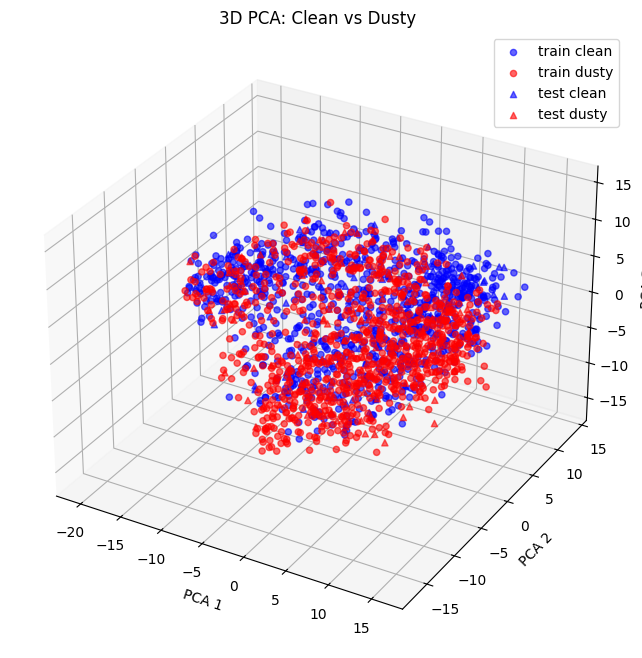

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

color_map = {'clean': 'blue', 'dusty': 'red'}
marker_map = {'train': 'o', 'test': '^'}

for split in ['train', 'test']:
    for label in ['clean', 'dusty']:
        mask = (splits_np == split) & (labels_np == label)
        # Ensure mask has at least one point
        if mask.sum() > 0:
            ax.scatter(features_3d[mask, 0], features_3d[mask, 1], features_3d[mask, 2],
                       c=color_map[label], marker=marker_map[split],
                       label=f'{split} {label}', alpha=0.6, s=20)
        else:
            print(f"No points for split={split}, label={label}")

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('3D PCA: Clean vs Dusty')
ax.legend()
plt.show()

In [26]:
!pip install plotly

  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached narwhals-2.21.0-py3-none-any.whl.metadata (16 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 218.4 kB/s  0:00:43a 0:00:010:00:03:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]━━━━ 1/2 [plotly]

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


## Interactive 3D plots

In [27]:
import plotly.express as px
import pandas as pd
import numpy as np

# Assuming you already have:
# features_np   : numpy array (N, 1280)
# labels_np     : numpy array (N,)  with values 'clean' / 'dusty' (or 'dirty')
# splits_np     : numpy array (N,)  with values 'train' / 'test'
# If you haven't run PCA yet:
from sklearn.decomposition import PCA
pca3 = PCA(n_components=3)
features_3d = pca3.fit_transform(features_np)

# Create a DataFrame for easy plotting
df = pd.DataFrame({
    'PCA1': features_3d[:, 0],
    'PCA2': features_3d[:, 1],
    'PCA3': features_3d[:, 2],
    'Class': labels_np,          # 'clean' or 'dusty'
    'Split': splits_np           # 'train' or 'test'
})

# Map class to color
color_discrete_map = {'clean': 'blue', 'dusty': 'red'}

fig = px.scatter_3d(df, x='PCA1', y='PCA2', z='PCA3',
                    color='Class',
                    symbol='Split',   # different shape for train/test
                    color_discrete_map=color_discrete_map,
                    title='3D PCA: Clean vs Dusty (Interactive)',
                    labels={'Class': 'Label', 'Split': 'Dataset Split'},
                    opacity=0.7,
                    hover_data={'PCA1': ':.3f', 'PCA2': ':.3f', 'PCA3': ':.3f'})

# Improve layout
fig.update_traces(marker=dict(size=4))
fig.update_layout(scene=dict(
                    xaxis_title='PCA 1',
                    yaxis_title='PCA 2',
                    zaxis_title='PCA 3'),
                  width=900, height=700)

fig.show()

## NON-Linear 3D plots 

In [29]:
from sklearn.manifold import TSNE
import numpy as np

# Use your existing numpy arrays: features_np (N, 1280), labels_np, splits_np
tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30)
features_tsne_3d = tsne_3d.fit_transform(features_np)

print("t‑SNE complete. Shape:", features_tsne_3d.shape)

t‑SNE complete. Shape: (1984, 3)


In [30]:
# Optional subsample for speed
if len(features_np) > 5000:
    idx = np.random.choice(len(features_np), 5000, replace=False)
    features_sub = features_np[idx]
    labels_sub = labels_np[idx]
    splits_sub = splits_np[idx]
else:
    features_sub = features_np
    labels_sub = labels_np
    splits_sub = splits_np

tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30)
features_tsne_3d = tsne_3d.fit_transform(features_sub) 

In [32]:
import plotly.express as px
import pandas as pd

# Create DataFrame with all needed columns
df = pd.DataFrame({
    'tSNE1': features_tsne_3d[:, 0],
    'tSNE2': features_tsne_3d[:, 1],
    'tSNE3': features_tsne_3d[:, 2],
    'Class': labels_sub,      # 'clean' or 'dusty'
    'Split': splits_sub       # 'train' or 'test'
})

# Color mapping for classes
color_discrete_map = {'clean': 'blue', 'dusty': 'red'}

fig = px.scatter_3d(df, x='tSNE1', y='tSNE2', z='tSNE3',
                     color='Class',
                     symbol='Split',      # different marker shapes
                     color_discrete_map=color_discrete_map,
                     title='3D t‑SNE: Clean vs Dusty (Train/Test)',
                     labels={'Class': 'Label', 'Split': 'Dataset'},
                     opacity=0.7,
                     hover_data={'tSNE1': ':.2f', 'tSNE2': ':.2f', 'tSNE3': ':.2f'})

# Adjust marker size and layout
fig.update_traces(marker=dict(size=4))
fig.update_layout(scene=dict(
                    xaxis_title='t‑SNE 1',
                    yaxis_title='t‑SNE 2',
                    zaxis_title='t‑SNE 3'),
                  width=900, height=700)

fig.show()

## according to the vibusalization i can findout  that the fetures are not enough and not even dintinguished properly

- the main Question till now is if the data set is vivusally not seperable 
- How can the logistic regressio learn form it 

## Now we will train  a linear SVM and a NON-Linear-SVM to check the Hyper Planes are even seperable or not 

## Linear 

In [33]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode labels to 0/1 if needed (SVC handles strings too, but safer)
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_np)   # clean → 0, dusty → 1

In [34]:
linear_svm = SVC(kernel='linear', C=1.0)
linear_scores = cross_val_score(linear_svm, features_np, labels_encoded, 
                                cv=5, scoring='accuracy')
print(f"Linear SVM CV accuracy: {linear_scores.mean():.3f} (+/- {linear_scores.std():.3f})")

Linear SVM CV accuracy: 0.837 (+/- 0.027)


In [35]:
rbf_svm = SVC(kernel='rbf', gamma='scale', C=1.0)
rbf_scores = cross_val_score(rbf_svm, features_np, labels_encoded, 
                             cv=5, scoring='accuracy')
print(f"RBF SVM CV accuracy: {rbf_scores.mean():.3f} (+/- {rbf_scores.std():.3f})")

RBF SVM CV accuracy: 0.861 (+/- 0.024)


## maing the assumptions on a 2D- algorithm with the PCA 

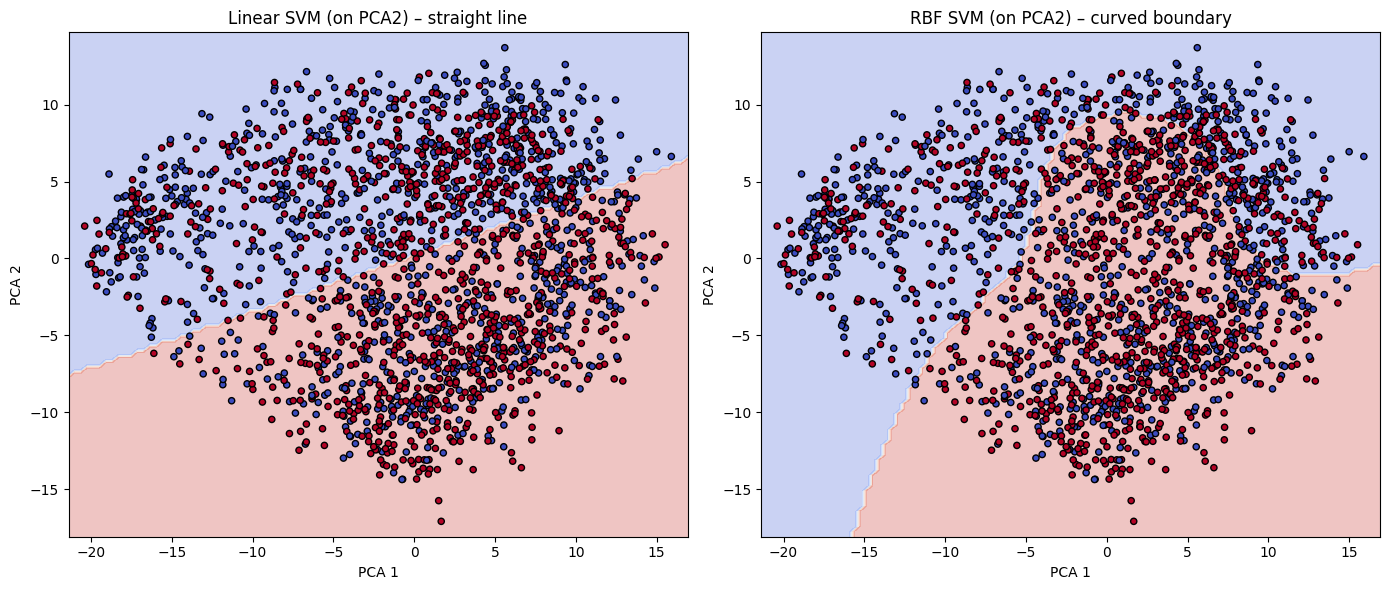

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# 1. Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(labels_np)   # clean=0, dusty=1

# 2. Reduce to 2D with PCA for visualization ONLY
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(features_np)   # shape (N, 2)

# 3. Train SVMs on the FULL 1280D data (not on PCA2)
linear_svm = SVC(kernel='linear', C=1.0).fit(features_np, y_enc)
rbf_svm = SVC(kernel='rbf', gamma='scale', C=1.0).fit(features_np, y_enc)

# 4. Create a mesh grid in PCA2 space
x_min, x_max = X_pca2[:, 0].min() - 1, X_pca2[:, 0].max() + 1
y_min, y_max = X_pca2[:, 1].min() - 1, X_pca2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

# 5. Helper: for each point in PCA2 mesh, we need to map back to 1280D
#    but that's impossible. Instead, we approximate by training SVMs on PCA2
#    just for visualization. This does NOT reflect the real 1280D boundary.
#    (We accept this as a didactic approximation)

linear_2d = SVC(kernel='linear', C=1.0).fit(X_pca2, y_enc)
rbf_2d = SVC(kernel='rbf', gamma='scale', C=1.0).fit(X_pca2, y_enc)

# 6. Predict on mesh
Z_linear = linear_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)
Z_rbf = rbf_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

# 7. Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear SVM decision boundary
axes[0].contourf(xx, yy, Z_linear, alpha=0.3, cmap='coolwarm')
axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_enc, cmap='coolwarm', edgecolor='k', s=20)
axes[0].set_title('Linear SVM (on PCA2) – straight line')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')

# RBF SVM decision boundary
axes[1].contourf(xx, yy, Z_rbf, alpha=0.3, cmap='coolwarm')
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_enc, cmap='coolwarm', edgecolor='k', s=20)
axes[1].set_title('RBF SVM (on PCA2) – curved boundary')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')

plt.tight_layout()
plt.show()

# working on the SVM with the TSNE 

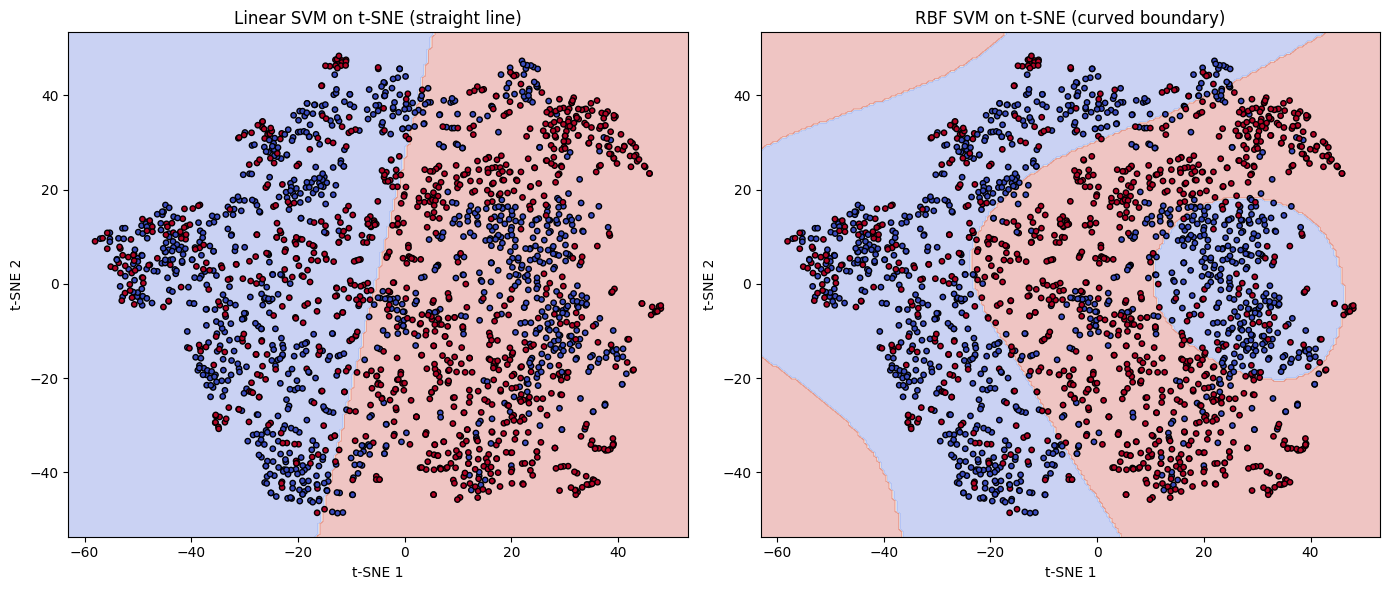

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder

# 1. Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(labels_np)   # clean=0, dusty=1

# 2. Compute 2D t‑SNE (if you haven't already)
#    Use a subset if dataset is large (>5000)
if len(features_np) > 5000:
    idx = np.random.choice(len(features_np), 5000, replace=False)
    X_sub = features_np[idx]
    y_sub = y_enc[idx]
else:
    X_sub = features_np
    y_sub = y_enc

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sub)

# 3. Train SVMs on the t‑SNE features (visualization only)
linear_svm_2d = SVC(kernel='linear', C=1.0).fit(X_tsne, y_sub)
rbf_svm_2d = SVC(kernel='rbf', gamma='scale', C=1.0).fit(X_tsne, y_sub)

# 4. Create mesh grid in t‑SNE space
x_min, x_max = X_tsne[:, 0].min() - 5, X_tsne[:, 0].max() + 5
y_min, y_max = X_tsne[:, 1].min() - 5, X_tsne[:, 1].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z_linear = linear_svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_linear = Z_linear.reshape(xx.shape)
Z_rbf = rbf_svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_rbf = Z_rbf.reshape(xx.shape)

# 5. Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear SVM on t‑SNE
axes[0].contourf(xx, yy, Z_linear, alpha=0.3, cmap='coolwarm')
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sub, cmap='coolwarm', edgecolor='k', s=15)
axes[0].set_title('Linear SVM on t‑SNE (straight line)')
axes[0].set_xlabel('t‑SNE 1')
axes[0].set_ylabel('t‑SNE 2')

# RBF SVM on t‑SNE
axes[1].contourf(xx, yy, Z_rbf, alpha=0.3, cmap='coolwarm')
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sub, cmap='coolwarm', edgecolor='k', s=15)
axes[1].set_title('RBF SVM on t‑SNE (curved boundary)')
axes[1].set_xlabel('t‑SNE 1')
axes[1].set_ylabel('t‑SNE 2')

plt.tight_layout()
plt.show()

## so i get the reason why the model fails 
- i see no truth validating the data 
- i see the data is not linearly seperable 
- the data is not even non linearly seperable 

#